# Building Perceptron : de l'exploration a la classification

## Introduction

Ce projet pedagogique du MSc IA & Data de La Plateforme consiste a developper une classe `Perceptron` en Python et a expliquer son fonctionnement a travers un probleme de classification binaire. Le notebook presente le controle et la preparation des donnees, leur analyse exploratoire, l'apprentissage, l'evaluation et les tests de fonctionnement auparavant dans un second notebook.

Le jeu Breast Cancer Wisconsin (Diagnostic), charge depuis scikit-learn, contient 569 observations et 30 mesures numeriques de noyaux cellulaires issus de prelevements de masses mammaires. Les colonnes decrivent des moyennes, des erreurs standard et des valeurs extremes (`worst`). Le diagnostic connu sert de cible : nous utilisons `0 = benigne` (non cancereuse), `1 = maligne` (cancereuse).

**Questions du projet :** quels controles de qualite sont necessaires ? Quelles mesures semblent distinguer les diagnostics ? La standardisation et une compression par ACP permettent-elles d'apprendre une classification utile avec un perceptron ? Comment ses erreurs se comparent-elles a celles d'une regression logistique ? Quelles limites revelent les tests AND et XOR ?

Ce travail est un exercice sur un jeu de reference, pas un dispositif de diagnostic medical. Sources : [description scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) et [jeu UCI](https://doi.org/10.24432/C5DW2B).

## 1. Chargement et preparation des donnees

Le jeu de donnees contient des mesures de tumeurs mammaires. La colonne `target` est recodee pour que `1` corresponde a une tumeur maligne et `0` a une tumeur benigne.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame

# sklearn utilise 0 pour malin et 1 pour benin; on inverse pour avoir 1 = malin.
df["target"] = 1 - df["target"]

## 2. Apercu et statistiques descriptives

`head()` montre cinq observations; `info()` donne les types et les valeurs presentes; `describe().T` resume chaque colonne (moyenne, dispersion, minimum, quartiles, maximum).

**Interpretation :** les mesures sont numeriques. Les echelles different fortement : le rayon moyen va d'environ 6,98 a 28,11 et l'aire moyenne de 143,5 a 2501, tandis que d'autres mesures sont proches de 0,1. Une standardisation est donc pertinente pour l'apprentissage du perceptron et l'ACP. Ces statistiques seules ne prouvent pas qu'une variable permet de predire le diagnostic.

In [3]:
display(df.head())

df.info()

display(df.describe().T)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3. Controle de qualite et nettoyage

On compte les valeurs manquantes et les lignes dupliquees avant de decider d'une correction.

**Resultat et decision :** les deux comptes sont nuls. Il n'y a donc pas d'imputation ni de suppression justifiee par ces controles. Le nettoyage consiste ici a verifier le jeu et a documenter le codage de la cible, pas a modifier arbitrairement les observations. Les points extremes des boxplots ne sont pas automatiquement des erreurs et sont conserves. L'absence de valeurs manquantes ne garantit pas l'absence de biais d'echantillonnage.

In [4]:
missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())

print(f"Valeurs manquantes : {missing_total}")
print(f"Lignes dupliquees : {duplicate_total}")

Valeurs manquantes : 0
Lignes dupliquees : 0


### Repartition des diagnostics

Le tableau et les barres donnent les effectifs et les proportions des deux classes.

**Interpretation :** 357 observations sont benignes (62,7 %) et 212 malignes (37,3 %). Le desequilibre est modere. Predire systematiquement benin donnerait deja 62,7 % de bonnes reponses sur le jeu complet, sans detecter un seul cas malin. On regarde donc aussi le rappel malin et les faux negatifs, et on utilise une separation stratifiee pour conserver les proportions.

In [5]:
class_counts = df["target"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Nombre de cas": class_counts,
    "Proportion (%)": (class_counts / len(df) * 100).round(1),
})
class_distribution.index = class_distribution.index.map({0: "Benigne (0)", 1: "Maligne (1)"})

display(class_distribution)

,Nombre de cas,Proportion (%)
target,,
Benigne (0),357,62.7
Maligne (1),212,37.3


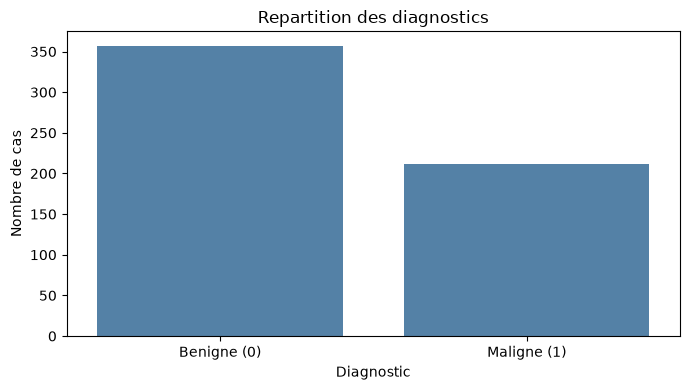

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="target", order=[0, 1], color="steelblue")
plt.xticks([0, 1], ["Benigne (0)", "Maligne (1)"])
plt.xlabel("Diagnostic")
plt.ylabel("Nombre de cas")
plt.title("Repartition des diagnostics")
plt.tight_layout()
plt.show()

## 4. Distributions des variables selon la cible

Ces boxplots comparent trois exemples de mesures selon le diagnostic. Ce choix illustratif n'est pas une selection des trois meilleures variables; la modelisation conserve toutes les mesures, puis teste leur compression par ACP.

**Lecture :** l'axe horizontal indique le diagnostic, l'axe vertical la mesure. La ligne dans la boite est la mediane; la boite couvre les 50 % centraux des valeurs. Les moustaches s'etendent aux observations situees dans la limite de 1,5 fois l'ecart interquartile; les points au-dela sont representes separement. Ils ne sont pas necessairement des erreurs.

**Interpretation :** le rayon moyen et les points concaves moyens sont generalement plus eleves pour les cas malins et leurs boites se separent plus nettement. La texture moyenne se chevauche davantage. Ces associations suggerent un pouvoir discriminant, mais aucune de ces figures ne demontre une separation parfaite ni une relation causale.

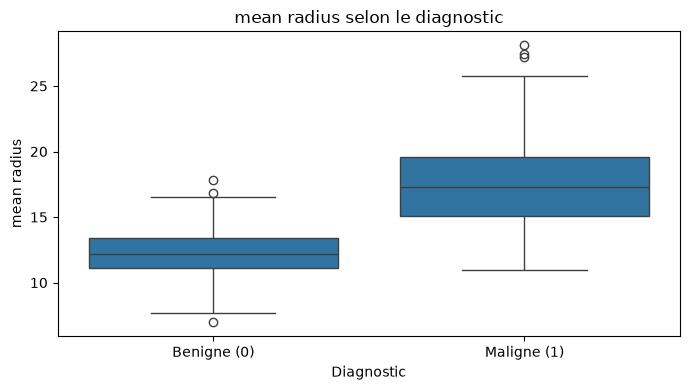

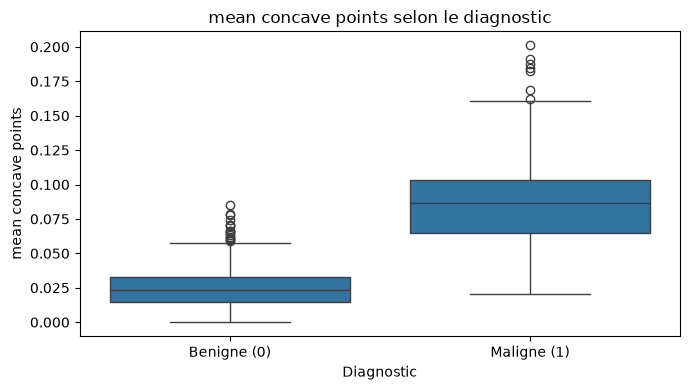

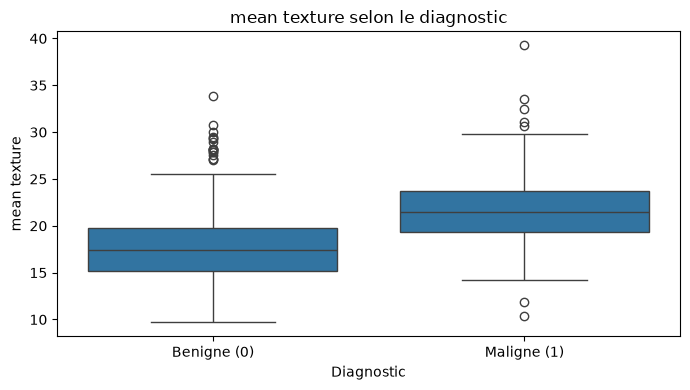

In [7]:
features_to_compare = ["mean radius", "mean concave points", "mean texture"]

for feature in features_to_compare:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="target", y=feature, data=df, order=[0, 1])
    plt.xticks([0, 1], ["Benigne (0)", "Maligne (1)"])
    plt.xlabel("Diagnostic")
    plt.ylabel(feature)
    plt.title(f"{feature} selon le diagnostic")
    plt.tight_layout()
    plt.show()

## 5. Correlations et redondance des mesures

La matrice utilise la correlation lineaire de Pearson. Une case proche de +1 indique que les deux mesures augmentent souvent ensemble; proche de -1, qu'elles varient en sens oppose; proche de 0, qu'il n'y a pas de relation lineaire forte. La diagonale vaut 1 car chaque mesure est comparee a elle-meme. La colonne `target` permet aussi de voir les associations lineaires au diagnostic recode.

**Interpretation :** rayon, perimetre et aire sont fortement lies, car ils decrivent notamment la taille. Certaines colonnes portent donc une information redondante. Cela motive une comparaison avec l'ACP, sans supprimer automatiquement les variables. L'ACP conserve de la variance, pas necessairement ce qui distingue le mieux les diagnostics. Une correlation n'est pas une preuve de causalite.

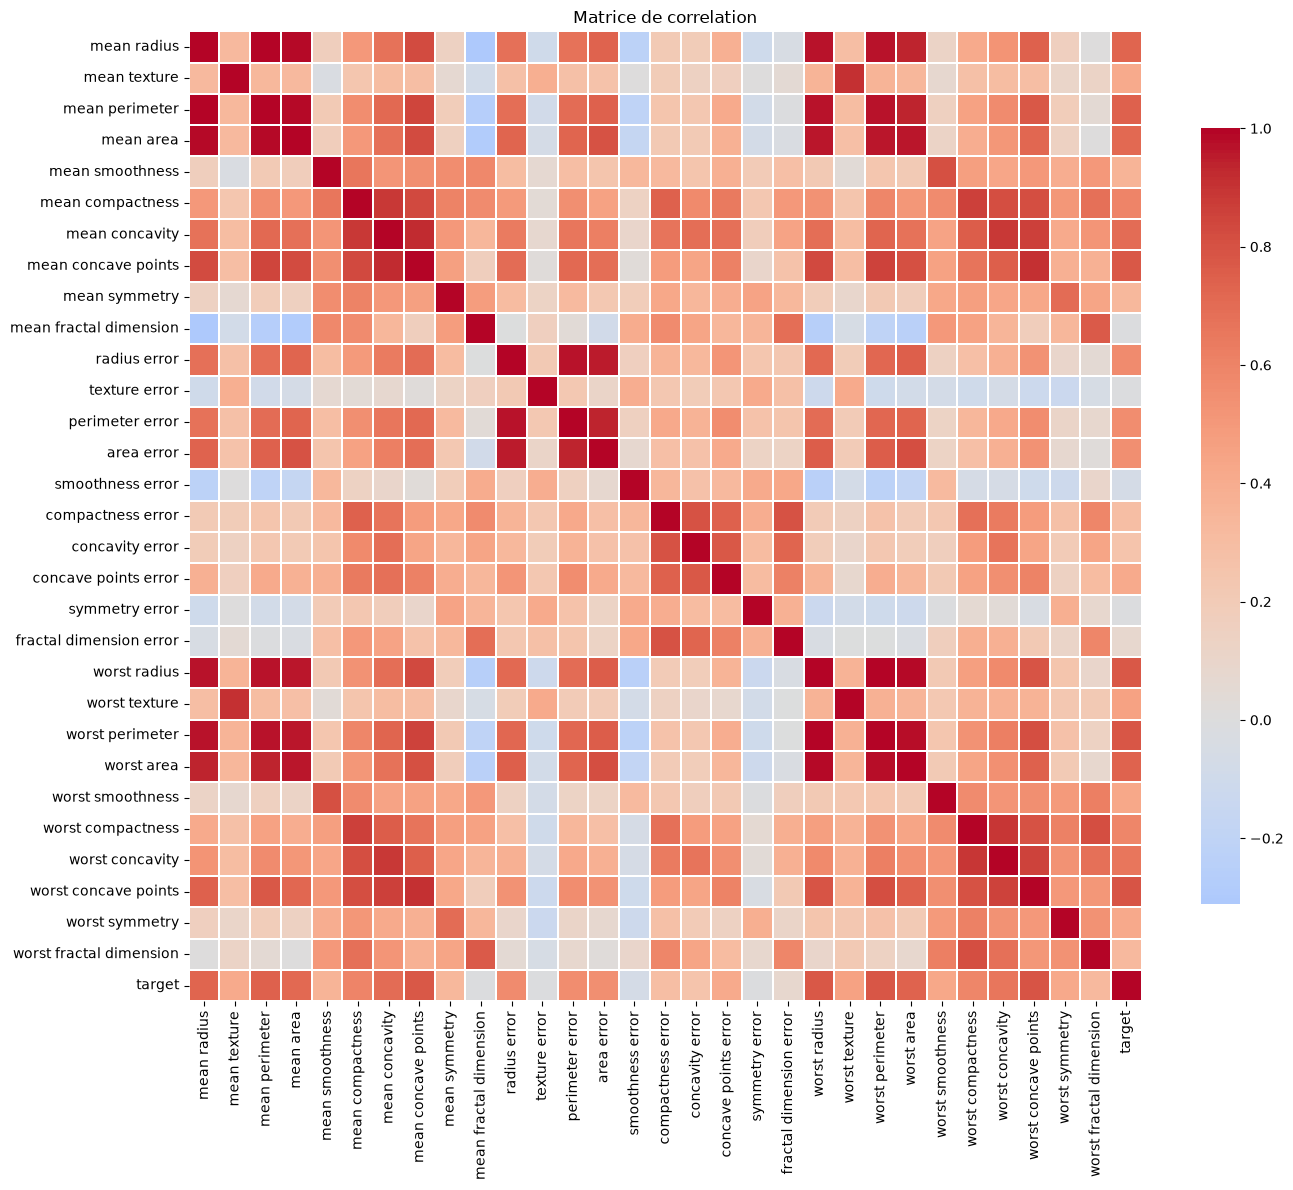

In [8]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

### Bilan de l'analyse exploratoire

Les controles ne revelent ni valeur manquante ni doublon. Les classes sont moderement desequilibrees, certaines mesures ont des echelles tres differentes et plusieurs sont correlees. Les distributions suggèrent que certaines mesures distinguent les diagnostics, avec des chevauchements persistants.

Ces constats motivent une separation stratifiee, une standardisation et une comparaison avec une ACP. Les trois boxplots ne constituent pas une selection de variables. L'EDA ayant examine le jeu complet, les scores suivants restent exploratoires; une evaluation confirmatoire demanderait un test reserve avant l'exploration.

## 6. Preparer, compresser, entrainer et evaluer

### 6.1. Separer les indices, les reponses et le test

- `X` contient les 30 mesures (les indices); `y` contient le diagnostic connu (la reponse).
- 80 % des exemples servent a apprendre; les 20 % restants servent de controle, comme un examen avec de nouvelles questions.
- `stratify=y` conserve approximativement la proportion de chaque diagnostic dans les deux groupes.
- `random_state=42` rend le tirage reproductible; 42 n'est pas un reglage qui rend le modele meilleur.

On retire `target` de `X` pour ne pas donner la reponse au modele.

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from perceptron import Perceptron

X = df.drop(columns="target").values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Apprentissage : {X_train.shape[0]} exemples, {X_train.shape[1]} mesures")
print(f"Test : {X_test.shape[0]} exemples, {X_test.shape[1]} mesures")

Apprentissage : 455 exemples, 30 mesures
Test : 114 exemples, 30 mesures


### 6.2. Mettre les mesures a une echelle comparable

`StandardScaler` recentre chaque mesure autour de 0 et ajuste sa dispersion. Cela facilite l'apprentissage du perceptron et evite qu'une mesure domine l'ACP uniquement parce que ses nombres sont grands.

`fit` apprend la moyenne et l'ecart-type sur l'apprentissage seulement; `transform` applique cette meme regle aux deux groupes. Le test ne doit pas servir a choisir cette regle. On ne standardise pas `y`.

In [13]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Moyennes apres standardisation (5 premieres mesures) :")
print(np.round(X_train_s.mean(axis=0)[:5], 3))
print("Ecarts-types correspondants :")
print(np.round(X_train_s.std(axis=0)[:5], 3))

Moyennes apres standardisation (5 premieres mesures) :
[-0.  0. -0.  0.  0.]
Ecarts-types correspondants :
[1. 1. 1. 1. 1.]


### 6.3. Compresser avec l'ACP

L'ACP fabrique de nouveaux indices en melangeant les 30 mesures. Elle ne choisit pas simplement quelques colonnes originales.

`n_components=0.95` garde assez de composantes pour conserver au moins 95 % de la variance des mesures standardisees d'apprentissage. Ce n'est pas 95 % de bonnes predictions: l'ACP ne regarde pas les diagnostics pour fabriquer ses composantes.

Sur le graphique: l'axe horizontal compte les composantes; l'axe vertical indique la variance conservee en les additionnant. La ligne rouge marque 95 %. La courbe s'arrete au nombre de composantes retenu.

ACP : 30 mesures deviennent 10 composantes
Variance conservee : 95.2%


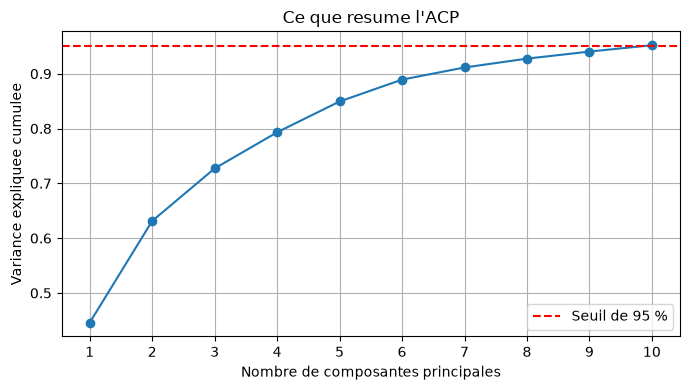

In [14]:
pca = PCA(n_components=0.95).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)
n_composantes = np.arange(1, len(variance_cumulee) + 1)

print(f"ACP : {X_train_s.shape[1]} mesures deviennent {pca.n_components_} composantes")
print(f"Variance conservee : {variance_cumulee[-1]:.1%}")

plt.figure(figsize=(7, 4))
plt.plot(n_composantes, variance_cumulee, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="Seuil de 95 %")
plt.xticks(n_composantes)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquee cumulee")
plt.title("Ce que resume l'ACP")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 6.4. Entrainer deux perceptrons et predire

On compare le meme algorithme avec deux representations des memes exemples: les 30 mesures standardisees, puis les composantes de l'ACP.

- `fit` apprend les poids avec les indices et les diagnostics d'apprentissage.
- `learning_rate=0.01` regle la taille des corrections.
- `n_epochs=50` fait parcourir les exemples d'apprentissage 50 fois; cela ne garantit pas un apprentissage parfait.
- `predict` donne un diagnostic pour les exemples de test, sans recevoir leurs vraies reponses.

`np.mean(y_pred == y_test)` est la proportion totale de bonnes reponses (accuracy), pas la precision d'une classe du rapport suivant.

In [15]:
p = Perceptron(learning_rate=0.01, n_epochs=50).fit(X_train_s, y_train)
y_pred = p.predict(X_test_s)

p_p = Perceptron(learning_rate=0.01, n_epochs=50).fit(X_train_p, y_train)
y_pred_p = p_p.predict(X_test_p)

print(f"Perceptron sans ACP : {np.mean(y_pred == y_test):.1%} de bonnes reponses")
print(f"Perceptron avec ACP : {np.mean(y_pred_p == y_test):.1%} de bonnes reponses")

Perceptron sans ACP : 94.7% de bonnes reponses
Perceptron avec ACP : 97.4% de bonnes reponses


### 6.5. Lire le bulletin et les matrices de confusion

Le rapport compare les predictions aux vrais diagnostics:

- `precision` : parmi les predictions d'une classe, quelle proportion est correcte ?
- `recall` (rappel) : parmi les vrais exemples de cette classe, quelle proportion a ete retrouvee ?
- `f1-score` : resume la precision et le rappel; plus il est proche de 1, mieux c'est.
- `support` : nombre de vrais exemples de cette classe dans le test.
- `accuracy` : proportion de bonnes reponses sur tout le test.
- `macro avg` : moyenne donnant le meme poids aux deux classes; `weighted avg` : moyenne ponderee par leurs effectifs.

Dans chaque matrice, les lignes sont les vrais diagnostics et les colonnes les predictions:

| Vrai diagnostic / Prediction | Benigne | Maligne |
| --- | --- | --- |
| Benigne | Bonne reponse | Fausse alerte |
| Maligne | Cas malin manque | Bonne reponse |

La diagonale contient les bonnes reponses. La case en bas a gauche compte les cas malins manques: il faut la regarder en plus du score global. Ces tests pedagogiques ne valident pas un outil medical.


Perceptron sans ACP
              precision    recall  f1-score   support

     Benigne       0.95      0.97      0.96        72
     Maligne       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



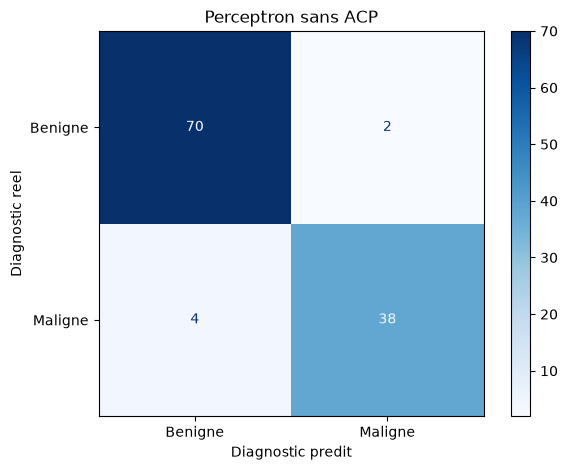


Perceptron avec ACP
              precision    recall  f1-score   support

     Benigne       0.97      0.99      0.98        72
     Maligne       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



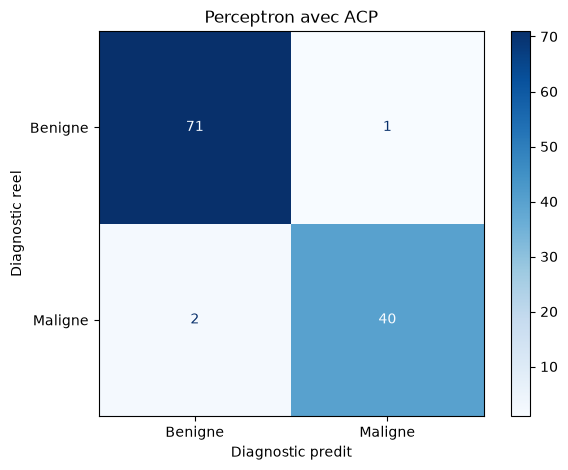

In [16]:
perceptron_predictions = [
    ("Perceptron sans ACP", y_pred),
    ("Perceptron avec ACP", y_pred_p),
]

for model_name, predictions in perceptron_predictions:
    print(f"\n{model_name}")
    print(classification_report(
        y_test, predictions, labels=[0, 1],
        target_names=["Benigne", "Maligne"], zero_division=0,
    ))
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=["Benigne", "Maligne"]).plot(cmap="Blues")
    plt.xlabel("Diagnostic predit")
    plt.ylabel("Diagnostic reel")
    plt.title(model_name)
    plt.tight_layout()
    plt.show()

### 6.6. Comparer avec la regression logistique

La regression logistique est un autre modele de classification. Malgre son nom, elle peut predire ici benin ou malin. Elle apprend des poids autrement que le perceptron; elle n'est pas automatiquement le meilleur modele.

On l'entraine sur les memes exemples, avec et sans ACP, puis on utilise le meme test pour comparer les quatre configurations. On lit les rapports et les matrices de la meme facon.


Regression logistique sans ACP
              precision    recall  f1-score   support

     Benigne       0.96      0.99      0.97        72
     Maligne       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



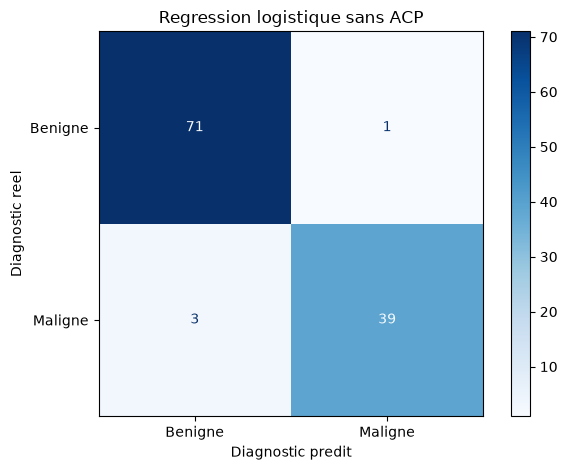


Regression logistique avec ACP
              precision    recall  f1-score   support

     Benigne       0.96      1.00      0.98        72
     Maligne       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



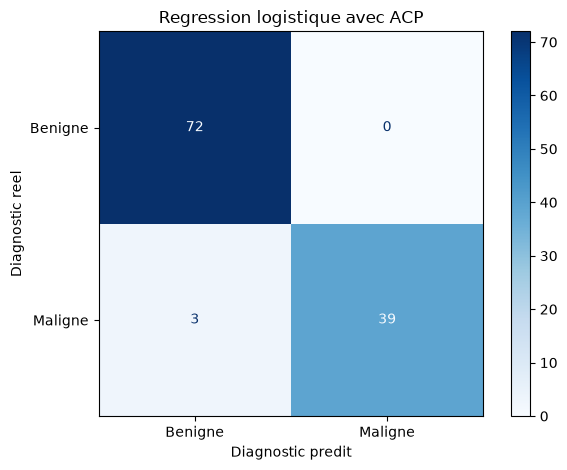

In [17]:
lr = LogisticRegression().fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

lr_p = LogisticRegression().fit(X_train_p, y_train)
y_pred_lr_p = lr_p.predict(X_test_p)

logistic_predictions = [
    ("Regression logistique sans ACP", y_pred_lr),
    ("Regression logistique avec ACP", y_pred_lr_p),
]

for model_name, predictions in logistic_predictions:
    print(f"\n{model_name}")
    print(classification_report(
        y_test, predictions, labels=[0, 1],
        target_names=["Benigne", "Maligne"], zero_division=0,
    ))
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=["Benigne", "Maligne"]).plot(cmap="Blues")
    plt.xlabel("Diagnostic predit")
    plt.ylabel("Diagnostic reel")
    plt.title(model_name)
    plt.tight_layout()
    plt.show()

### 6.7. Comparer les resultats sans oublier les limites

Le tableau regroupe les quatre modeles sur le meme test. Le rappel malin indique la proportion des vrais cas malins retrouves. Les cas malins manques et les fausses alertes expliquent les erreurs cachees par un score global.

Un bon score sur ce seul tirage ne prouve ni une superiorite generale de l'ACP ni une fiabilite medicale. Pour choisir et regler un modele, on utilise une validation sur l'apprentissage (par exemple une validation croisee), puis un test final reserve. Comme l'EDA a deja examine l'ensemble des donnees, cette comparaison reste exploratoire.

In [18]:
comparison_rows = []

for model_name, predictions in perceptron_predictions + logistic_predictions:
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    comparison_rows.append({
        "Modele": model_name,
        "Bonnes reponses (%)": round(np.mean(predictions == y_test) * 100, 1),
        "Rappel malin (%)": round(matrix[1, 1] / matrix[1].sum() * 100, 1),
        "Cas malins manques": int(matrix[1, 0]),
        "Fausses alertes": int(matrix[0, 1]),
    })

comparison = pd.DataFrame(comparison_rows).set_index("Modele")
display(comparison)

,Bonnes reponses (%),Rappel malin (%),Cas malins manques,Fausses alertes
Modele,,,,
Perceptron sans ACP,94.7,90.5,4,2
Perceptron avec ACP,97.4,95.2,2,1
Regression logistique sans ACP,96.5,92.9,3,1
Regression logistique avec ACP,97.4,92.9,3,0


## 7. Developpement et validation du perceptron

La classe de `perceptron.py` a ete developpee avec NumPy; les modeles scikit-learn servent a la preparation et a la comparaison, pas a implementer ce perceptron.

Pour une observation $x$, le score est $s = w^T x + b$. La prediction vaut 1 si $s \geq 0$, sinon 0. Avec l'erreur $e = y - \hat y$ et le taux $\eta$, les corrections sont $w \leftarrow w + \eta e x$ et $b \leftarrow b + \eta e$. Les poids et le biais sont initialises a zero. `fit` retourne le modele; `net_input` calcule le score; `predict` applique le seuil; `errors_` conserve les erreurs faites pendant chaque passe.

Les experiences ci-dessous reprennent le contenu utile du second notebook dans ce notebook unique. Elles verifient le fonctionnement et rendent visible la limite d'une frontiere lineaire.

### 7.1. Test de fonctionnement : la porte AND

AND donne 1 uniquement si ses deux entrees valent 1. Les assertions verifient les predictions et l'historique. Le score est mesure sur les quatre exemples de la table logique : il s'agit d'un test fonctionnel, pas d'une preuve de generalisation sur les donnees medicales.

In [19]:
and_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
and_targets = np.array([0, 0, 0, 1])
and_model = Perceptron(learning_rate=0.1, n_epochs=20)
assert and_model.fit(and_inputs, and_targets) is and_model
and_predictions = and_model.predict(and_inputs)
np.testing.assert_array_equal(and_predictions, and_targets)
assert and_predictions.shape == and_targets.shape
assert len(and_model.errors_) == 20
assert and_model.errors_[-1] == 0
np.testing.assert_array_equal(and_model.predict(np.array([[1, 1], [0, 1]])), [1, 0])

print("Test AND reussi :", and_predictions)
print("Poids :", and_model.weights, "Biais :", and_model.bias)
print("Erreurs pendant les passes :", and_model.errors_)

Test AND reussi : [0 0 0 1]
Poids : [0.2 0.1] Biais : -0.20000000000000004
Erreurs pendant les passes : [2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### 7.2. Limite geometrique : XOR

XOR vaut 1 quand les deux entrees sont differentes. Les points de meme classe occupent des coins opposes du carre : aucune droite ne separe parfaitement les deux classes. Augmenter le nombre de passes ne change pas cette impossibilite pour les entrees originales.

Sur le graphique de gauche, les couleurs indiquent les vraies classes; la droite noire est la frontiere du modele. A droite, `errors_` compte les erreurs faites pendant chaque passe, avec des poids qui evoluent. Ce n'est pas le nombre d'erreurs du modele final.

**Interpretation :** l'echec sur XOR est attendu. L'assertion d'au moins une erreur confirme ce comportement sur cette execution; c'est l'argument geometrique, et non cette seule assertion, qui explique la limite generale.

Predictions XOR : [1 1 0 0] Attendu : [0 1 1 0]
Erreurs du modele final : 2 sur 4


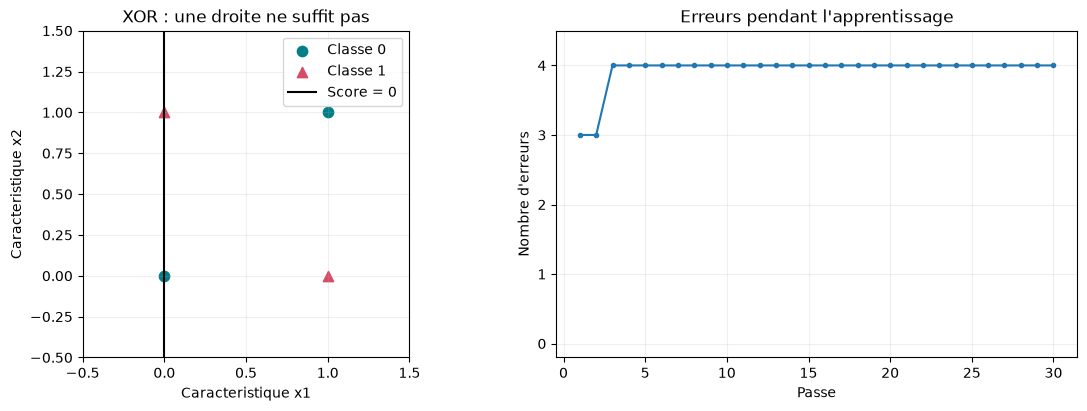

In [20]:
def plot_decision(axis, inputs, targets, trained_model):
    for label, color, marker in [(0, "#007f86", "o"), (1, "#d64b65", "^")]:
        points = inputs[targets == label]
        axis.scatter(points[:, 0], points[:, 1], c=color, marker=marker,
                     label=f"Classe {label}", s=55)
    lower = inputs.min(axis=0) - 0.5
    upper = inputs.max(axis=0) + 0.5
    first_weight, second_weight = trained_model.weights
    if second_weight != 0:
        horizontal = np.linspace(lower[0], upper[0], 200)
        vertical = -(first_weight * horizontal + trained_model.bias) / second_weight
        axis.plot(horizontal, vertical, color="black", label="Score = 0")
    elif first_weight != 0:
        axis.axvline(-trained_model.bias / first_weight, color="black", label="Score = 0")
    else:
        axis.text(0.05, 0.95, "Poids nuls : pas de droite", transform=axis.transAxes, va="top")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.set_xlabel("Caracteristique x1")
    axis.set_ylabel("Caracteristique x2")
    axis.legend()
    axis.grid(alpha=0.2)

xor_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_targets = np.array([0, 1, 1, 0])
xor_epochs = 30
xor_model = Perceptron(learning_rate=0.1, n_epochs=xor_epochs).fit(xor_inputs, xor_targets)
xor_predictions = xor_model.predict(xor_inputs)
xor_final_errors = int(np.count_nonzero(xor_predictions != xor_targets))
assert xor_predictions.shape == xor_targets.shape
assert xor_final_errors > 0
print("Predictions XOR :", xor_predictions, "Attendu :", xor_targets)
print("Erreurs du modele final :", xor_final_errors, "sur 4")

xor_figure, xor_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_decision(xor_axes[0], xor_inputs, xor_targets, xor_model)
xor_axes[0].set_title("XOR : une droite ne suffit pas")
xor_axes[0].set_aspect("equal", adjustable="box")
xor_axes[1].plot(np.arange(1, xor_epochs + 1), xor_model.errors_, marker="o", markersize=3)
xor_axes[1].set_title("Erreurs pendant l'apprentissage")
xor_axes[1].set_xlabel("Passe")
xor_axes[1].set_ylabel("Nombre d'erreurs")
xor_axes[1].set_ylim(-0.2, 4.5)
xor_axes[1].grid(alpha=0.2)
plt.show()

### 7.3. Donnees simulees et generalisation

On genere 60 points par classe autour de deux centres distincts, avec une dispersion de 0,8 et une graine de 42. Les nuages sont separes horizontalement; une frontiere lineaire convient a cette construction. Les exemples sont melanges puis separes en 90 points d'apprentissage et 30 points de test, sans recouvrement.

Les couleurs indiquent les vraies classes et la droite noire la frontiere apprise. Le meme modele est utilise dans les deux graphiques. Un score parfait sur ce probleme artificiel simple ne permet pas de conclure a un score parfait sur des donnees medicales. Une dispersion de 1,8 pourrait faire se chevaucher les nuages.

Accuracy apprentissage : 100.0%
Accuracy test : 100.0%


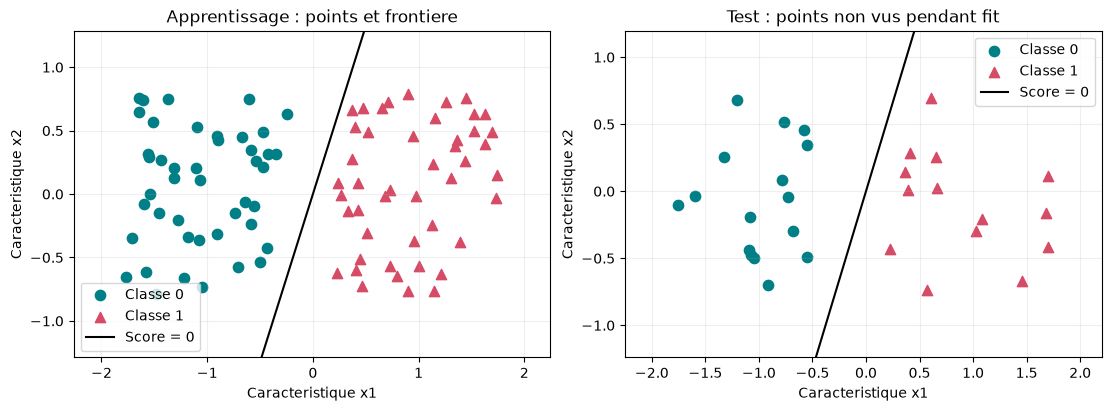

In [21]:
spread = 0.8
random_generator = np.random.default_rng(42)
points_per_class = 60
class_zero = np.array([-1.0, 0.0]) + random_generator.uniform(-spread, spread, (points_per_class, 2))
class_one = np.array([1.0, 0.0]) + random_generator.uniform(-spread, spread, (points_per_class, 2))
random_inputs = np.vstack([class_zero, class_one])
random_targets = np.concatenate([np.zeros(points_per_class, dtype=int), np.ones(points_per_class, dtype=int)])
shuffled_indices = random_generator.permutation(len(random_targets))
split_index = int(0.75 * len(random_targets))
train_indices = shuffled_indices[:split_index]
test_indices = shuffled_indices[split_index:]
random_train_inputs, random_train_targets = random_inputs[train_indices], random_targets[train_indices]
random_test_inputs, random_test_targets = random_inputs[test_indices], random_targets[test_indices]
assert not np.intersect1d(train_indices, test_indices).size

random_model = Perceptron(learning_rate=0.1, n_epochs=40).fit(random_train_inputs, random_train_targets)
test_predictions = random_model.predict(random_test_inputs)
assert test_predictions.shape == random_test_targets.shape
print(f"Accuracy apprentissage : {np.mean(random_model.predict(random_train_inputs) == random_train_targets):.1%}")
print(f"Accuracy test : {np.mean(test_predictions == random_test_targets):.1%}")

random_figure, random_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_decision(random_axes[0], random_train_inputs, random_train_targets, random_model)
random_axes[0].set_title("Apprentissage : points et frontiere")
plot_decision(random_axes[1], random_test_inputs, random_test_targets, random_model)
random_axes[1].set_title("Test : points non vus pendant fit")
plt.show()

### 7.4. Taux d'apprentissage et erreurs par passe

On compare $\eta = 0,01$, $0,1$ et $1$ sur les memes nuages et sur XOR pendant 40 passes. Une passe est un parcours complet de l'apprentissage. Les erreurs de `errors_` se produisent pendant que les poids changent; elles ne mesurent pas directement les erreurs finales sur le test.

**Interpretation :** les nuages separes atteignent zero erreur, contrairement a XOR. Dans cette implementation initialisee a zero, avec un taux constant positif, le meme ordre des exemples et sans regularisation, changer le taux multiplie les poids et le biais par ce facteur sans changer mathematiquement le signe des scores. Les courbes peuvent donc se superposer. Ce constat specifique au perceptron utilise ici ne signifie pas que le taux est sans importance pour tous les algorithmes.

eta=0.01 : accuracy test nuages=100.0%, erreurs finales XOR=2/4
eta=0.1 : accuracy test nuages=100.0%, erreurs finales XOR=2/4
eta=1.0 : accuracy test nuages=100.0%, erreurs finales XOR=2/4


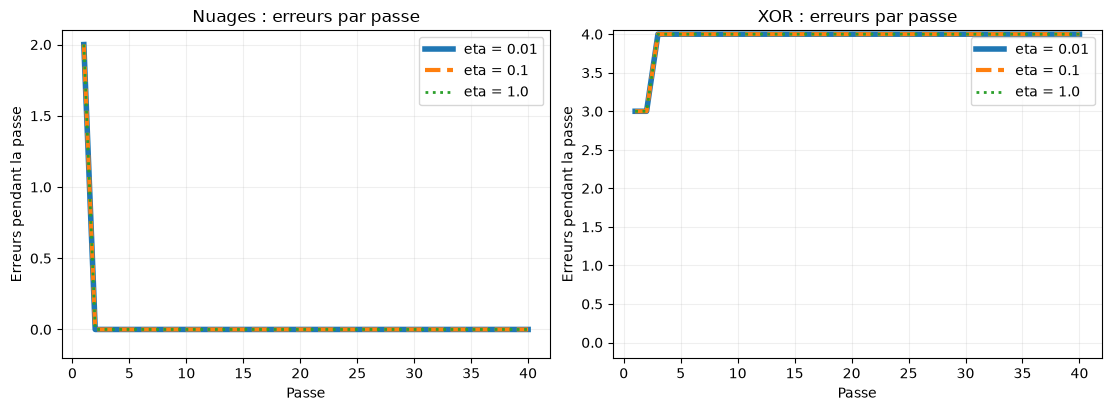

Nuages : courbes identiques pour les taux testes ? True
XOR : courbes identiques pour les taux testes ? True


In [22]:
eta_values = [0.01, 0.1, 1.0]
comparison_epochs = 40
epoch_numbers = np.arange(1, comparison_epochs + 1)
comparison_histories = {"Nuages": [], "XOR": []}
line_styles = ["-", "--", ":"]
comparison_figure, comparison_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for eta_index, eta in enumerate(eta_values):
    cloud_model = Perceptron(learning_rate=eta, n_epochs=comparison_epochs).fit(random_train_inputs, random_train_targets)
    comparison_xor_model = Perceptron(learning_rate=eta, n_epochs=comparison_epochs).fit(xor_inputs, xor_targets)
    comparison_histories["Nuages"].append(cloud_model.errors_)
    comparison_histories["XOR"].append(comparison_xor_model.errors_)
    comparison_axes[0].plot(epoch_numbers, cloud_model.errors_, linestyle=line_styles[eta_index],
                            linewidth=4 - eta_index, label=f"eta = {eta}")
    comparison_axes[1].plot(epoch_numbers, comparison_xor_model.errors_, linestyle=line_styles[eta_index],
                            linewidth=4 - eta_index, label=f"eta = {eta}")
    cloud_accuracy = np.mean(cloud_model.predict(random_test_inputs) == random_test_targets)
    comparison_xor_errors = np.count_nonzero(comparison_xor_model.predict(xor_inputs) != xor_targets)
    assert comparison_xor_errors > 0
    assert len(cloud_model.errors_) == comparison_epochs
    print(f"eta={eta} : accuracy test nuages={cloud_accuracy:.1%}, erreurs finales XOR={comparison_xor_errors}/4")

for axis, title in zip(comparison_axes, ["Nuages : erreurs par passe", "XOR : erreurs par passe"]):
    axis.set_title(title)
    axis.set_xlabel("Passe")
    axis.set_ylabel("Erreurs pendant la passe")
    axis.set_ylim(bottom=-0.2)
    axis.legend()
    axis.grid(alpha=0.2)
plt.show()

for dataset_name, histories in comparison_histories.items():
    identical = all(np.array_equal(histories[0], history) for history in histories[1:])
    print(f"{dataset_name} : courbes identiques pour les taux testes ? {identical}")

### 7.5. Apprentissage sur les donnees medicales

La courbe suivante suit les erreurs pendant chaque passe pour les deux perceptrons du jeu Breast Cancer. Une baisse indique moins de corrections pendant l'apprentissage. Une courbe non nulle n'est pas necessairement un bug : les classes peuvent se chevaucher et les poids evoluent pendant la passe. La performance sur le test se lit dans les rapports et les matrices de la section 6, pas dans cette courbe seule.

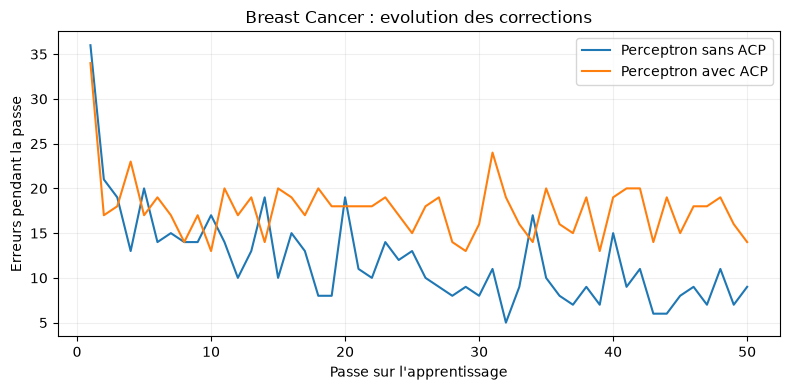

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(p.errors_) + 1), p.errors_, label="Perceptron sans ACP")
plt.plot(np.arange(1, len(p_p.errors_) + 1), p_p.errors_, label="Perceptron avec ACP")
plt.xlabel("Passe sur l'apprentissage")
plt.ylabel("Erreurs pendant la passe")
plt.title("Breast Cancer : evolution des corrections")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Conclusion generale

La classe Perceptron a ete developpee et testee sur AND, XOR et des nuages simules. AND est appris; XOR conserve des erreurs car les classes ne sont pas lineairement separables. Les nuages separes donnent 100 % sur leur test artificiel, sans justifier une generalisation aux donnees medicales.

Sur Breast Cancer, les controles ne trouvent ni valeur manquante ni doublon. Les echelles different et certaines mesures sont redondantes, ce qui motive la standardisation et la comparaison avec l'ACP. Cette derniere conserve 10 composantes et environ 95,2 % de variance. Sur les 114 observations de test, le perceptron sans ACP obtient 94,7 % d'accuracy avec 4 cas malins manques; avec ACP, 97,4 % avec 2 cas malins manques et 1 fausse alerte. La regression logistique avec ACP obtient aussi 97,4 %, mais manque 3 cas malins et ne produit aucune fausse alerte. Un score global identique peut donc cacher des consequences differentes.

L'ACP ameliore ici le resultat du perceptron, mais n'est pas garantie meilleure sur tous les tirages. Les corrections restent non nulles pendant l'apprentissage, ce qui ne contredit pas les bons scores sur ce test. Les parametres 0,01 et 50 passes sont les reglages de l'experience, pas des valeurs optimales demontrees.

**Limites et perspectives :** le jeu est petit, de reference et non representatif de tous les contextes cliniques. L'EDA a examine l'ensemble des observations; le test a servi a comparer plusieurs configurations. Une prochaine etape serait une validation croisee stratifiee uniquement sur l'apprentissage, avec standardisation et ACP reajustees dans chaque pli, puis une evaluation finale sur un test non consulte. Ce projet montre un procede de developpement et ses limites; il ne valide pas un outil medical.

## 9. Bibliographie et reproduction

Executer toutes les cellules dans l'ordre depuis la racine du depot, avec le noyau Python contenant NumPy, pandas, Matplotlib, Seaborn et scikit-learn. Le README fournit les commandes d'installation. `perceptron.py` reste le script de la classe; ce notebook unique rassemble l'EDA, la modelisation et les tests auparavant separes.

- Rosenblatt, F. (1958), *The Perceptron*, Psychological Review : https://doi.org/10.1037/h0042519
- UCI, *Breast Cancer Wisconsin (Diagnostic)* : https://doi.org/10.24432/C5DW2B
- scikit-learn, donnees : https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- scikit-learn, standardisation : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- scikit-learn, ACP : https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- scikit-learn, evaluation : https://scikit-learn.org/stable/modules/model_evaluation.html
- scikit-learn, regression logistique : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html